In [2]:
from google.colab import drive
drive.mount('/content/drive')

!pip install diffusers transformers accelerate safetensors insightface onnxruntime opencv-python-headless -q
!pip install ip-adapter facexlib gfpgan -q

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 762.2/762.2 kB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 104.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 106.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 13.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.5/172.5 kB 11.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.2/52.2 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.1/333.1 kB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 151.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 28.4 MB/s eta 0:00:00


In [3]:
import os

PROJECT_ROOT = "/content/Lab6_CV"
os.makedirs(PROJECT_ROOT, exist_ok=True)

MODEL_DIR = os.path.join(PROJECT_ROOT, "models")
IMAGES_DIR = os.path.join(PROJECT_ROOT, "generated_images")
SOURCE_DIR = os.path.join(PROJECT_ROOT, "source_photos")

for dir_path in [MODEL_DIR, IMAGES_DIR, SOURCE_DIR]:
    os.makedirs(dir_path, exist_ok=True)

print(f"Thư mục dự án: {PROJECT_ROOT}")
print(f"Tải ảnh lên: {SOURCE_DIR}")

Thư mục dự án: /content/Lab6_CV
Tải ảnh lên: /content/Lab6_CV/source_photos


In [5]:
#  Tải model IP-Adapter

import torch
from diffusers import StableDiffusionPipeline, DDIMScheduler

SD_MODEL = "runwayml/stable-diffusion-v1-5"
ADAPTER_PATH = os.path.join(MODEL_DIR, "ip_adapter_faceid.bin")

# Tải adapter nếu chưa có
if not os.path.exists(ADAPTER_PATH):
    !wget -q "https://huggingface.co/h94/IP-Adapter-FaceID/resolve/main/ip-adapter-faceid_sd15.bin" \
        -O {ADAPTER_PATH}
    print("Downloaded IP-Adapter FaceID")

scheduler = DDIMScheduler.from_pretrained(SD_MODEL, subfolder="scheduler")
pipe = StableDiffusionPipeline.from_pretrained(
    SD_MODEL,
    scheduler=scheduler,
    torch_dtype=torch.float16,
    safety_checker=None,
    requires_safety_checker=False
)
pipe = pipe.to("cuda")

pipe.enable_attention_slicing()

print("Model loaded successfully")

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully


In [6]:
#  Khởi tạo Face Analyzer và IP-Adapter

from insightface.app import FaceAnalysis
from ip_adapter.ip_adapter_faceid import IPAdapterFaceID
import cv2
import numpy as np

# Face analysis
face_analyzer = FaceAnalysis(
    name="buffalo_l",
    providers=['CUDAExecutionProvider', 'CPUExecutionProvider']
)
face_analyzer.prepare(ctx_id=0, det_size=(640, 640))
print("Face analyzer sẵn sàng")

# IP-Adapter
face_adapter = IPAdapterFaceID(
    pipe,
    ADAPTER_PATH,
    device="cuda"
)
print("IP-Adapter FaceID sẵn sàng")

download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:02<00:00, 96415.49KB/s]
/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:149: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
Face analyze

/usr/local/lib/python3.12/dist-packages/diffusers/models/lora.py:206: FutureWarning: `LoRALinearLayer` is deprecated and will be removed in version 1.0.0. Use of `LoRALinearLayer` is deprecated. Please switch to PEFT backend by installing PEFT: `pip install peft`.
  deprecate("LoRALinearLayer", "1.0.0", deprecation_message)


IP-Adapter FaceID sẵn sàng


UPLOAD ẢNH KHUÔN MẶT CỦA BẠN


Saving photo_5226944250157669852_y.jpg to photo_5226944250157669852_y.jpg
Saving photo_5226944250157669853_y.jpg to photo_5226944250157669853_y.jpg
Saving photo_5226944250157669862_y.jpg to photo_5226944250157669862_y.jpg
Saving photo_5226944250157669863_x.jpg to photo_5226944250157669863_x.jpg
Saving photo_5226944250157669866_y.jpg to photo_5226944250157669866_y.jpg
Đã lưu: photo_5226944250157669852_y.jpg
Đã lưu: photo_5226944250157669853_y.jpg
Đã lưu: photo_5226944250157669862_y.jpg
Đã lưu: photo_5226944250157669863_x.jpg
Đã lưu: photo_5226944250157669866_y.jpg
DANH SÁCH ẢNH ĐÃ UPLOAD:
1. photo_5226944250157669853_y.jpg
2. photo_5226944250157669852_y.jpg
3. photo_5226944250157669863_x.jpg
4. photo_5226944250157669862_y.jpg
5. photo_5226944250157669866_y.jpg

Tổng số: 5 ảnh


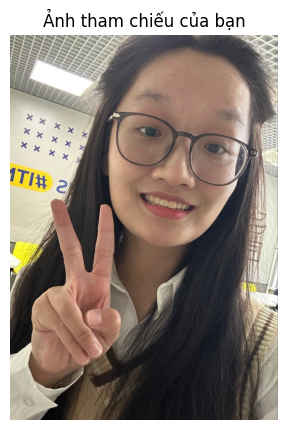

In [9]:
# Upload ảnh khuôn mặt

from google.colab import files
import os
import shutil

SOURCE_DIR = "/content/Lab6_CV/source_photos"
os.makedirs(SOURCE_DIR, exist_ok=True)

print("UPLOAD ẢNH KHUÔN MẶT CỦA BẠN")

uploaded = files.upload()

for filename, content in uploaded.items():
    filepath = os.path.join(SOURCE_DIR, filename)
    with open(filepath, 'wb') as f:
        f.write(content)
    print(f"Đã lưu: {filename}")

print("DANH SÁCH ẢNH ĐÃ UPLOAD:")

import glob
image_paths = glob.glob(os.path.join(SOURCE_DIR, "*.[jJ][pP][gG]")) + \
               glob.glob(os.path.join(SOURCE_DIR, "*.[pP][nN][gG]"))

for i, path in enumerate(image_paths, 1):
    print(f"{i}. {os.path.basename(path)}")

print(f"\nTổng số: {len(image_paths)} ảnh")

# Hiển thị ảnh đầu tiên
if len(image_paths) > 0:
    from PIL import Image
    import matplotlib.pyplot as plt

    sample = Image.open(image_paths[0])
    plt.figure(figsize=(5,5))
    plt.imshow(sample)
    plt.title("Ảnh tham chiếu của bạn", fontsize=12)
    plt.axis("off")
    plt.show()

In [10]:
#  Trích xuất đặc trưng khuôn mặt

def extract_face_features(image_paths, face_analyzer):
    """Trích xuất face embedding từ nhiều ảnh"""
    embeddings = []
    valid_images = []

    for img_path in image_paths:
        img = cv2.imread(img_path)
        if img is None:
            continue

        # Resize về kích thước chuẩn
        img = cv2.resize(img, (640, 640))

        # Phát hiện khuôn mặt
        faces = face_analyzer.get(img)

        if len(faces) > 0:
            face = faces[0]
            if face.det_score > 0.5:  # Chỉ lấy mặt có chất lượng tốt
                embeddings.append(face.normed_embedding)
                valid_images.append(img_path)
                print(f"Đã nhận diện: {os.path.basename(img_path)} (score: {face.det_score:.2f})")
            else:
                print(f"Chất lượng thấp: {os.path.basename(img_path)}")
        else:
            print(f"Không tìm thấy mặt: {os.path.basename(img_path)}")

    if len(embeddings) == 0:
        raise ValueError("Không có ảnh nào hợp lệ!")

    # Lấy embedding trung bình để tăng độ chính xác
    avg_embedding = np.mean(embeddings, axis=0)
    face_tensor = torch.from_numpy(avg_embedding).unsqueeze(0).float()

    print(f"\nTổng hợp từ {len(embeddings)} ảnh")
    return face_tensor.to("cuda")

# Trích xuất
face_embedding = extract_face_features(image_paths, face_analyzer)

Đã nhận diện: photo_5226944250157669853_y.jpg (score: 0.71)
Đã nhận diện: photo_5226944250157669852_y.jpg (score: 0.74)
Đã nhận diện: photo_5226944250157669863_x.jpg (score: 0.82)
Không tìm thấy mặt: photo_5226944250157669862_y.jpg
Đã nhận diện: photo_5226944250157669866_y.jpg (score: 0.58)

Tổng hợp từ 4 ảnh


 Đang test sinh ảnh...


  0%|          | 0/30 [00:00<?, ?it/s]

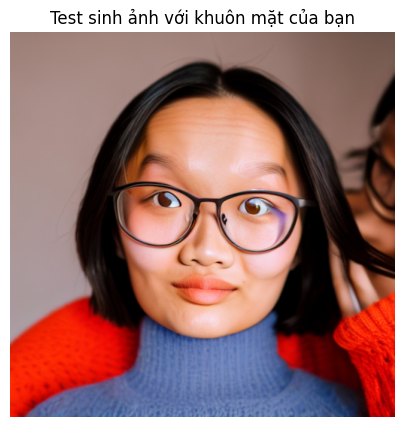

Test thành công.


In [13]:
# Hàm sinh ảnh với face preservation

def generate_with_my_face(
    prompt,
    face_embedding,
    adapter,
    num_steps=50,
    guidance_scale=7.5,
    face_strength=0.85,
    seed=None
):
    """
    Sinh ảnh giữ được khuôn mặt
    - prompt: text mô tả
    - face_strength: độ mạnh của face preservation (0.5-1.0)
    """
    # Tạo generator cho seed
    generator = torch.Generator(device="cuda").manual_seed(seed) if seed is not None else None

    # Gọi adapter.generate - KHÔNG truyền generator qua kwargs
    images = adapter.generate(
        prompt=prompt,
        faceid_embeds=face_embedding,
        num_samples=1,
        num_inference_steps=num_steps,
        guidance_scale=guidance_scale,
        scale=face_strength,
        seed=seed
    )
    return images[0]

# Test thử
print(" Đang test sinh ảnh...")
test_img = generate_with_my_face(
    "portrait photo, high quality, detailed face",
    face_embedding,
    face_adapter,
    num_steps=30,
    seed=42
)

plt.figure(figsize=(5,5))
plt.imshow(test_img)
plt.title("Test sinh ảnh với khuôn mặt của bạn", fontsize=12)
plt.axis("off")
plt.show()
print("Test thành công.")

Đang thử seed 42...


  0%|          | 0/60 [00:00<?, ?it/s]

Đang thử seed 123...


  0%|          | 0/60 [00:00<?, ?it/s]

Đang thử seed 456...


  0%|          | 0/60 [00:00<?, ?it/s]

Đang thử seed 789...


  0%|          | 0/60 [00:00<?, ?it/s]

Đang thử seed 101112...


  0%|          | 0/60 [00:00<?, ?it/s]

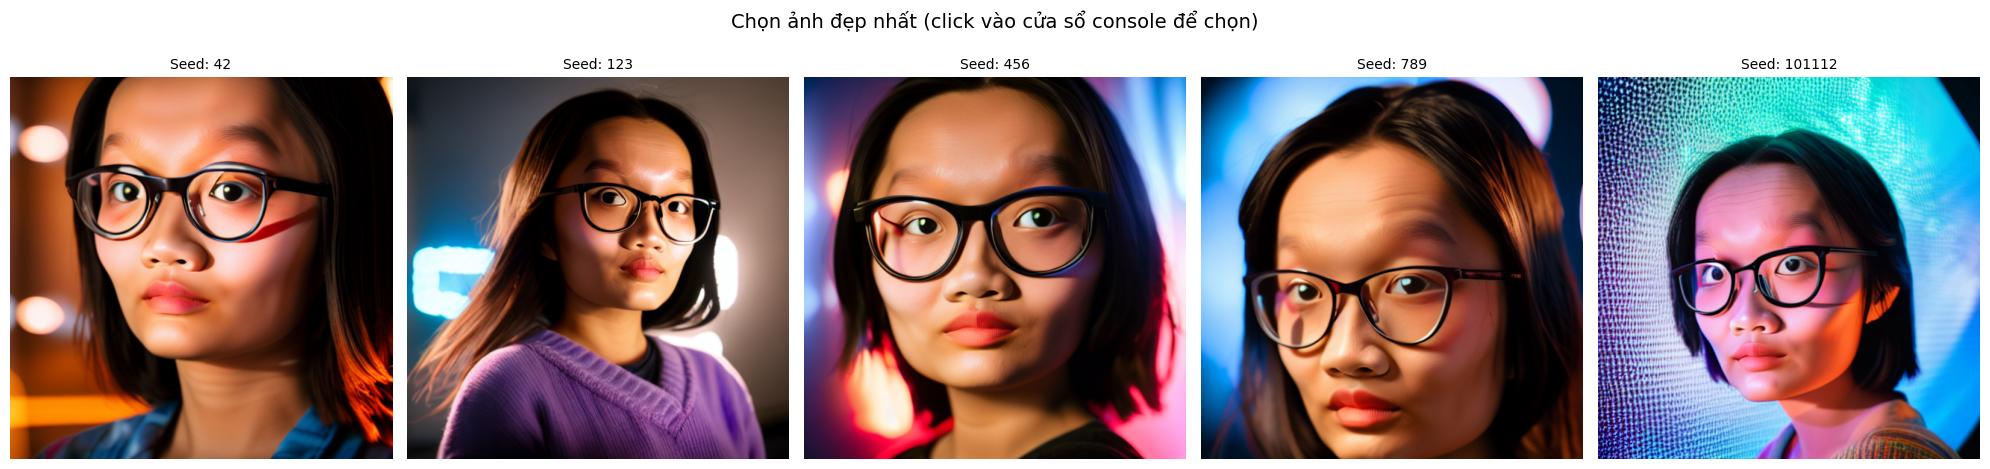


Nhập seed của ảnh đẹp nhất (42/123/456/789/101112): 123
Đã lưu ảnh chất lượng cao tại: /content/Lab6_CV/generated_images/best_quality_image.png


In [14]:
#  Tạo 1 ảnh chất lượng cao nhất
# Prompt được tối ưu cho chất lượng cao
best_prompt = """
a girl, professional photograph, cinematic lighting,
detailed face, sharp focus, 8K resolution,
masterpiece, award winning photo
""".strip()

# Thử nhiều seed để chọn ảnh đẹp nhất
candidates = []
seeds_to_try = [42, 123, 456, 789, 101112]

for seed in seeds_to_try:
    print(f"Đang thử seed {seed}...")
    img = generate_with_my_face(
        prompt=best_prompt,
        face_embedding=face_embedding,
        adapter=face_adapter,
        num_steps=60,
        guidance_scale=8.0,
        face_strength=0.9,
        seed=seed
    )
    candidates.append((seed, img))

# Hiển thị để chọn
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, (seed, img) in enumerate(candidates):
    axes[i].imshow(img)
    axes[i].set_title(f"Seed: {seed}", fontsize=10)
    axes[i].axis("off")
plt.suptitle("Chọn ảnh đẹp nhất (click vào cửa sổ console để chọn)", fontsize=14)
plt.tight_layout()
plt.show()

# Chọn ảnh đẹp nhất
choice = input("\nNhập seed của ảnh đẹp nhất (42/123/456/789/101112): ")
best_seed = int(choice)
best_image = next(img for s, img in candidates if s == best_seed)

# Lưu
best_image.save(os.path.join(IMAGES_DIR, "best_quality_image.png"))
print(f"Đã lưu ảnh chất lượng cao tại: {IMAGES_DIR}/best_quality_image.png")


 [1/5] Đang tạo: Victorian Era


  0%|          | 0/50 [00:00<?, ?it/s]


 [2/5] Đang tạo: Ice Queen


  0%|          | 0/50 [00:00<?, ?it/s]


 [3/5] Đang tạo: Flower Fairy


  0%|          | 0/50 [00:00<?, ?it/s]


 [4/5] Đang tạo: Art Deco


  0%|          | 0/50 [00:00<?, ?it/s]


 [5/5] Đang tạo: Underwater


  0%|          | 0/50 [00:00<?, ?it/s]

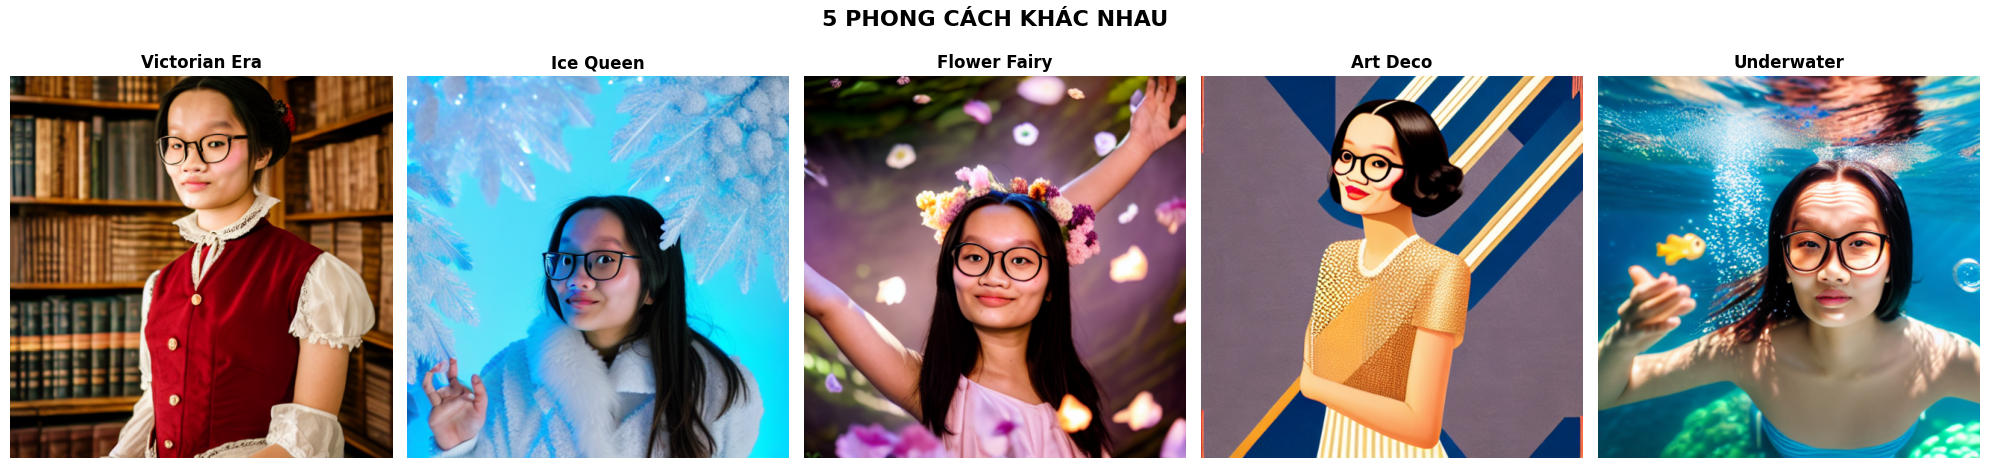


 Đã lưu 5 ảnh phong cách vào: /content/Lab6_CV/generated_images


In [15]:
# Tạo 5 ảnh theo phong cách khác nhau
style_configs = [
    {
        "name": "Victorian Era",
        "prompt": "a girl in victorian era dress, old library, vintage, high quality, realism"
    },
    {
        "name": "Ice Queen",
        "prompt": "a girl made of ice, frozen crystal, winter fantasy, snowflake details, high quality"
    },
    {
        "name": "Flower Fairy",
        "prompt": "a girl as flower fairy, petals floating, magical garden, soft lighting, high quality"
    },
    {
        "name": "Art Deco",
        "prompt": "a girl in art deco style, 1920s glamour, geometric patterns, gold details, high quality"
    },
    {
        "name": "Underwater",
        "prompt": "a girl underwater, bubbles, coral reef, ocean light rays, high quality, realism"
    }
]

style_images = []

for i, config in enumerate(style_configs, 1):
    print(f"\n [{i}/5] Đang tạo: {config['name']}")

    img = generate_with_my_face(
        prompt=config['prompt'],
        face_embedding=face_embedding,
        adapter=face_adapter,
        num_steps=50,
        guidance_scale=7.5,
        face_strength=0.85,
        seed=200 + i
    )
    style_images.append((config['name'], img))
    img.save(os.path.join(IMAGES_DIR, f"style_{i:02d}_{config['name']}.png"))

# Hiển thị grid 5 ảnh
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, (name, img) in enumerate(style_images):
    axes[i].imshow(img)
    axes[i].set_title(name, fontsize=12, fontweight='bold')
    axes[i].axis("off")
plt.suptitle("5 PHONG CÁCH KHÁC NHAU", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, "five_styles_collage.png"), dpi=150)
plt.show()

print(f"\n Đã lưu 5 ảnh phong cách vào: {IMAGES_DIR}")


 [1/3] Đang tạo: Forest


  0%|          | 0/55 [00:00<?, ?it/s]

   Đã lưu: location_01_Forest.png

 [2/3] Đang tạo: City


  0%|          | 0/55 [00:00<?, ?it/s]

   Đã lưu: location_02_City.png

 [3/3] Đang tạo: Beach


  0%|          | 0/55 [00:00<?, ?it/s]

   Đã lưu: location_03_Beach.png


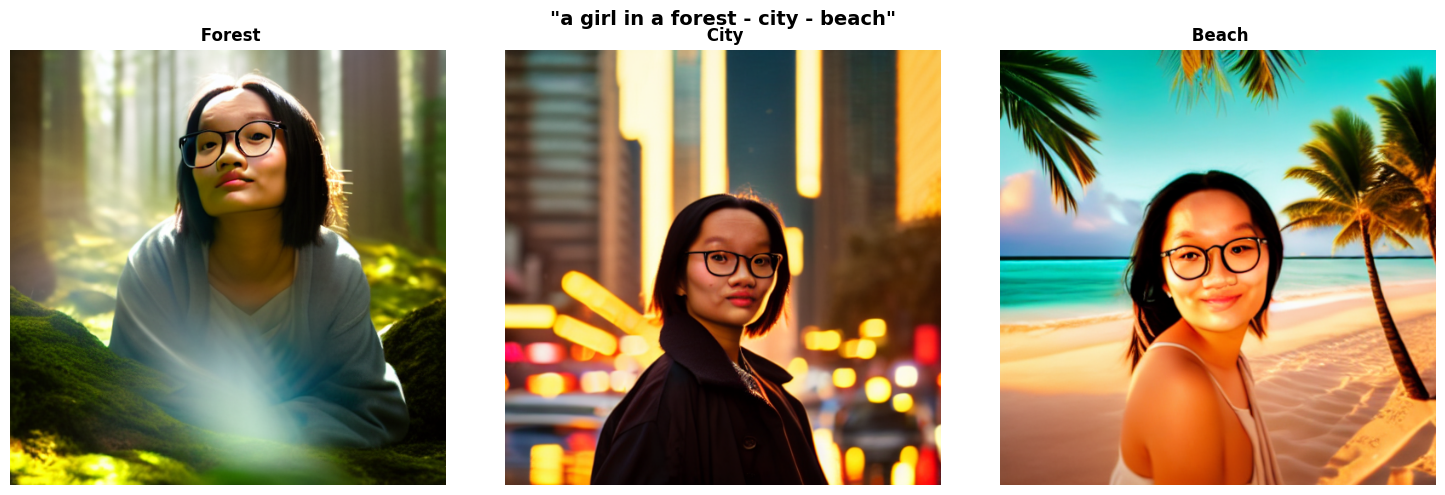


 Đã lưu 3 ảnh theo địa điểm vào: /content/Lab6_CV/generated_images


In [17]:
# Tạo 3 ảnh theo địa điểm (Yêu cầu chính) \
location_images = []

# Prompt template theo yêu cầu đề bài
locations = [
    ("Forest", "a mystical forest with tall pine trees, morning fog, sun rays through leaves, moss on ground, peaceful atmosphere"),
    ("City", "a bustling modern city street at golden hour, glass skyscrapers, city lights starting to glow, reflections on wet pavement"),
    ("Beach", "a pristine white sand beach with turquoise water, gentle waves, palm trees, golden sunset sky, tropical paradise")
]

for i, (name, location_detail) in enumerate(locations, 1):
    prompt = f"a girl in {location_detail}, high quality, realism"
    print(f"\n [{i}/3] Đang tạo: {name}")

    img = generate_with_my_face(
        prompt=prompt,
        face_embedding=face_embedding,
        adapter=face_adapter,
        num_steps=55,
        guidance_scale=7.5,
        face_strength=0.85,
        seed=300 + i
    )
    location_images.append((name, img))
    img.save(os.path.join(IMAGES_DIR, f"location_{i:02d}_{name}.png"))
    print(f"   Đã lưu: location_{i:02d}_{name}.png")

# Hiển thị kết quả
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, (name, img) in enumerate(location_images):
    axes[i].imshow(img)
    axes[i].set_title(f" {name}", fontsize=12, fontweight='bold')
    axes[i].axis("off")
plt.suptitle('"a girl in a forest - city - beach"', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, "three_locations.png"), dpi=150)
plt.show()

print(f"\n Đã lưu 3 ảnh theo địa điểm vào: {IMAGES_DIR}")